Load Dataset

In [4]:
import pandas as pd

_df = pd.read_excel('Dataset for Data Analytics.xlsx')

# View first rows
_df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


Understanding Dataset

In [5]:
_df.info()
_df.isnull().sum()
_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


Data Cleaning

In [6]:
# Remove duplicates
_df.drop_duplicates(inplace=True)

# Fill missing values
_df.fillna(0, inplace=True)

# Convert Date column
_df['Date'] = pd.to_datetime(_df['Date'])

Create Important Columns

In [7]:
_df['Revenue'] = _df['Quantity'] * _df['UnitPrice']

_df['Month'] = _df['Date'].dt.month_name()

Create Visualizations

Monthly Sales Trend (Line Chart)

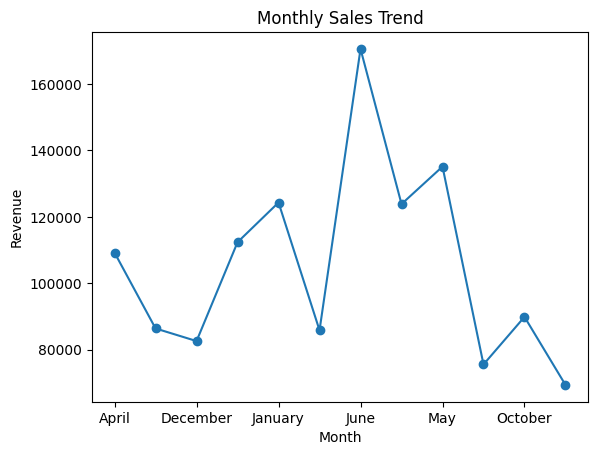

In [8]:
import matplotlib.pyplot as plt

monthly_sales = _df.groupby('Month')['Revenue'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

Top Selling Products (Bar Chart)

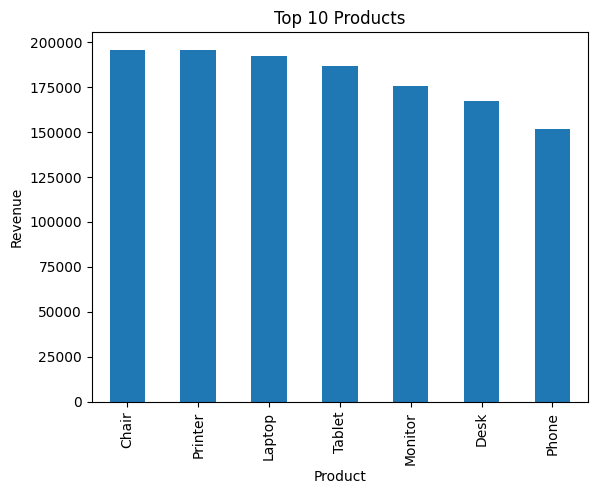

In [9]:
product_sales = _df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

product_sales.head(10).plot(kind='bar')
plt.title('Top 10 Products')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

Payment Method Distribution (Pie Chart)

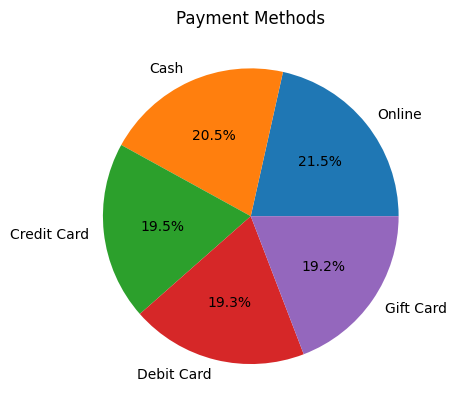

In [10]:
payment_counts = _df['PaymentMethod'].value_counts()

payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Payment Methods')
plt.ylabel('')
plt.show()

Order Status Analysis (Bar Chart)

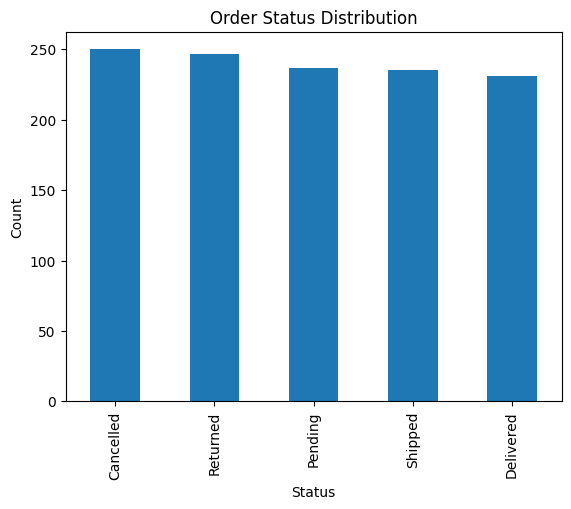

In [11]:
status_counts = _df['OrderStatus'].value_counts()

status_counts.plot(kind='bar')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

Referral Source Analysis

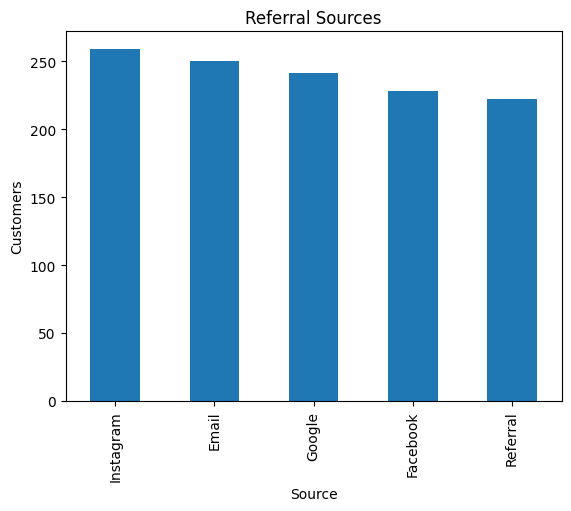

In [12]:
referral = _df['ReferralSource'].value_counts()

referral.plot(kind='bar')
plt.title('Referral Sources')
plt.xlabel('Source')
plt.ylabel('Customers')
plt.show()

Coupon Usage Analysis

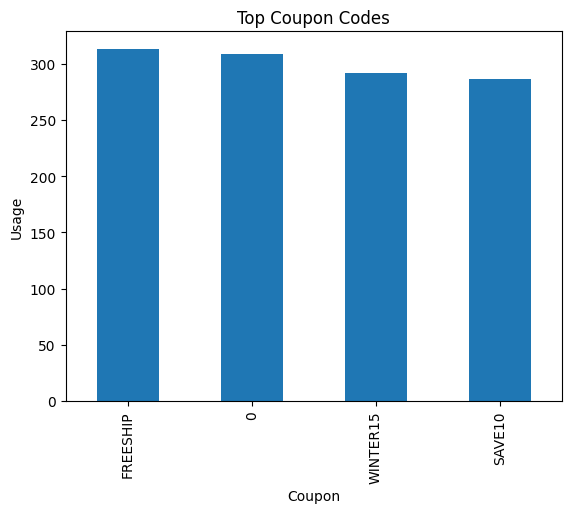

In [13]:
coupon_usage = _df['CouponCode'].value_counts()

coupon_usage.head(10).plot(kind='bar')
plt.title('Top Coupon Codes')
plt.xlabel('Coupon')
plt.ylabel('Usage')
plt.show()

Add Styling

In [14]:
import seaborn as sns
sns.set_style('whitegrid')

In [15]:
_df.to_excel('cleaned_dataset_project4.xlsx', index=False)